[*********************100%***********************]  1 of 1 completed

Random Walk p-value:  0.6669759383932888
Mean Reverting p-value:  2.443678742351955e-19


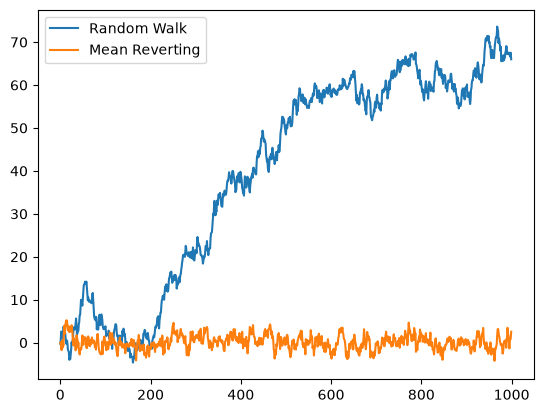

Cointegration p-value:  0.5367334407202361


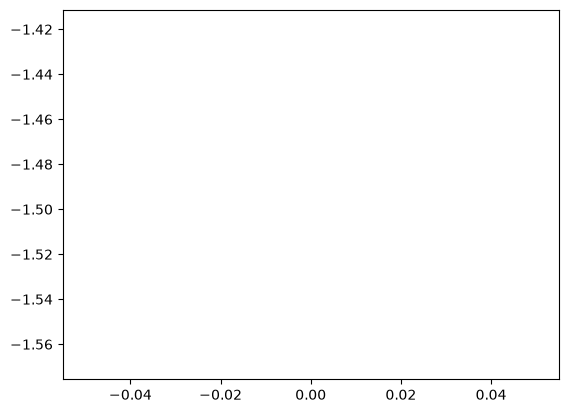

In [6]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

df = yf.download('KO', start = '2020-01-01', end = '2025-01-01')
random_walk = np.cumsum(np.random.normal(0,1,1000))

mean_reverting = np.zeros(1000)

noise = np.random.normal(0,1,1000)

for i in range(1,1000):
    mean_reverting[i] = 0.8 * mean_reverting[i-1] + noise[i]
#simulates the random walk process

result_rw = adfuller(random_walk)

result_rm = adfuller(mean_reverting)

print("Random Walk p-value: ", result_rw[1])




print("Mean Reverting p-value: ", result_rm[1])


plt.plot(random_walk, label = "Random Walk")
plt.plot(mean_reverting, label = "Mean Reverting")
plt.legend()

plt.show()

result_cola = adfuller(df['Close'])
print("Cointegration p-value: ", result_cola[1])
plt.plot(result_cola[0], label = "Cointegration")